# Easy peasy multisession registration

Working on a quick coding method for multisession registration so that we can run it through a pipeline.

This method takes advantage of the "intersection over union" technique employed by CaImAn. In fact, I hacked the code to make it work with everything suite2p!

TODO: Currently, a cell not being matched gets set to 0. This is a problem because 0-indexing. So, this code is almost functional!

In [1]:
import os; import matplotlib.pyplot as plt
path_added = os.path.split(os.path.split(os.getcwd())[0])[0]; os.chdir(path_added); print("Added path:",path_added)
import sessreg

import rootfun as rf # we can import this if our cwd is local
root = rf.dropbox_root(dropbox_folder='timspellman')

Added path: c:\Users\johnj\SpellmanLab Dropbox\timspellman\Python\John\PySpell\code


The important variable below is `max_distance` which will impact your yield.

`onlyAccepted`, when set to True, removes all rejected components. As face value, this seems like a good idea, but it might be cleaner to keep `onlyAccepted=False` and index out your accepted components that are also registered across sessions using `multireg['idx_cellmatch']`


`fnames` = paths to your data that has the suite2p path inside it

In [2]:
root

'c:\\Users\\johnj\\SpellmanLab Dropbox\\'

Assuming that the user wants the ROI to be present across the number of input paths =  2
ONLY INCLUDING ACCEPTED VARIABLES - this is not a flexible approach
Rewriting the `iscell` variable to only include accepted components
ONLY INCLUDING ACCEPTED VARIABLES - this is not a flexible approach
Rewriting the `iscell` variable to only include accepted components
Swapping dim
Swapping dim
Swapping dim
Swapping dim


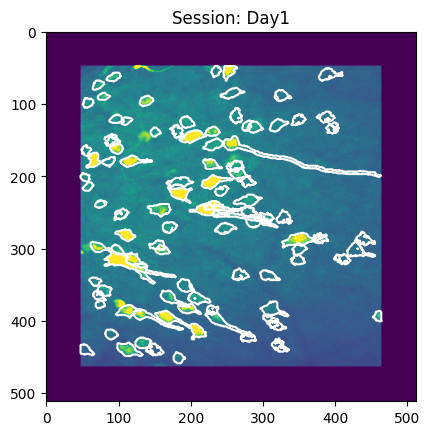

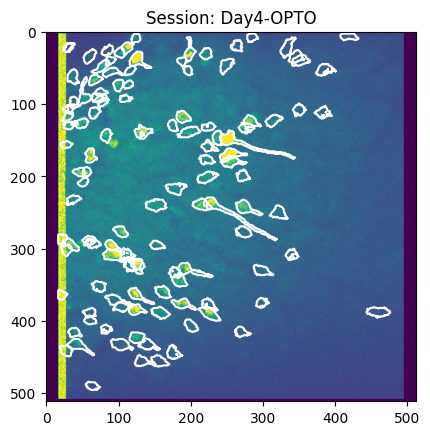

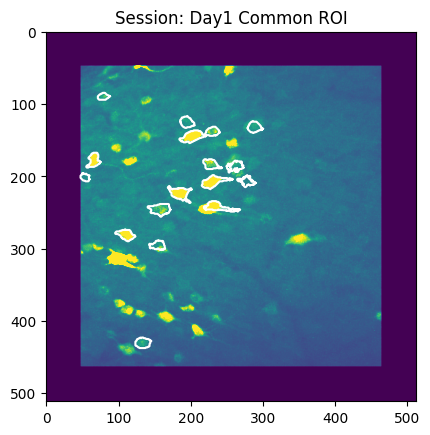

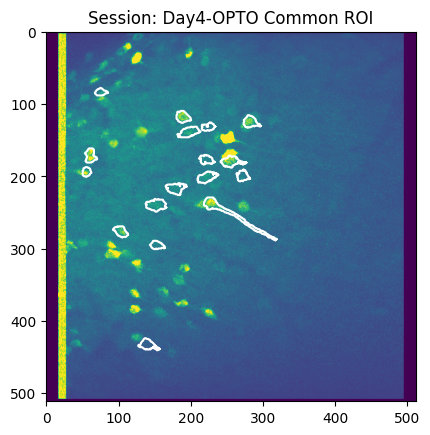

In [7]:
# these are test inputs. Feel free the change
'''
fnames = [os.path.join(root,r"timspellman\Imaging\PFCMDTReanalysis\Imaging\t400\SEDS1"),
          os.path.join(root,r"timspellman\Imaging\PFCMDTReanalysis\Imaging\t400\SEDS2"),
          os.path.join(root,r"timspellman\Imaging\PFCMDTReanalysis\Imaging\t400\SEDS3")]
          #os.path.join(root,r"timspellman\Imaging\PFCMDTReanalysis\Imaging\t400\SEDS4")]
'''
fnames = [os.path.join(root,r"OtherData\John\ProjectData\L6_IMGDRIVE_DATA\LAYER6\L6Chrimson_PanneuronalRec\T30\Sessions\SD1\FOV1\Day1"),
          os.path.join(root,r"OtherData\John\ProjectData\L6_IMGDRIVE_DATA\LAYER6\L6Chrimson_PanneuronalRec\T30\Sessions\SD1\FOV1\Day4-OPTO")]

# the important input is max_distance. You lower this and your yield drops
multireg, backgrounds, s2pdata = sessreg.multisess_register_suite2p(fnames=fnames, max_distance=100, onlyAccepted=True)

The outputs from sessreg are:

`multisess`: variables from multi-session registration

`backgrounds`: images extracted from suite2p

`s2pdata`: suite2p data

You access their elements as such: `multisess['SEDS1']`

In [4]:
print(multireg.keys())
print(backgrounds.keys())
print(s2pdata.keys())

dict_keys(['templates', 'Day1', 'Day4-OPTO', 'inputs', 'spatial_union', 'assignments', 'matchings', 'common_components'])
dict_keys(['Day1', 'Day4-OPTO'])
dict_keys(['Day1', 'Day4-OPTO'])


Here is the index of your common components per each session

Row = component

Col = session

Element = index of component per session that is aligned

In [5]:
multireg['common_components']

array([[  2,  62],
       [  3,  70],
       [  5,  57],
       [  7,  26],
       [  8,  24],
       [ 10, 127],
       [ 18, 115],
       [ 26,  87],
       [ 30, 100],
       [ 33,  10],
       [ 36,  52],
       [ 40,   9],
       [ 69, 113],
       [ 70,  95],
       [ 77,  27],
       [ 88,  93],
       [100,  84],
       [122, 131],
       [140, 110],
       [145,   5],
       [147, 140]])

The `sessreg` code also outputs an `s2pdata` key to tell you which components are both accepted by suite2p/manual curation and which components were accepted by session-registration

`s2pdata['yourSessionName']['iscell_reg']`

So you can use this to index out whatever.


First extract your deconvolved data `spks = s2pdata['SEDS1']['spks']`

Then extract your deconvolved data that pass the criterion for both **(1)** *being a cell* and **(2)** *being identified in multiple sessions*: `spksreg = spks[s2pdata['SEDS1']['iscell_reg']]`

In [5]:
spks    = s2pdata['SEDS1']['spks']
spk_reg = spks[s2pdata['SEDS1']['iscell_reg']]

Identify the exact cells from different sessions

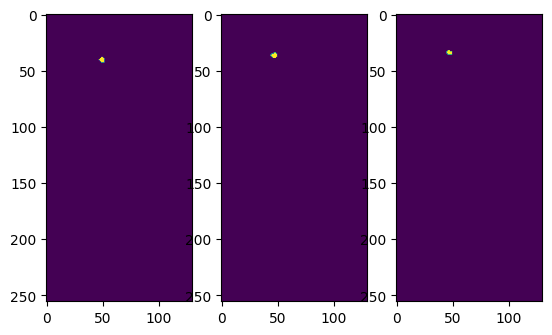

In [6]:
# here is the same component across 4 sessions
comp = 5; idx = multireg['common_components'][comp]

fig, ax = plt.subplots(nrows=1,ncols=3)
ax[0].imshow(s2pdata['SEDS1']['im'][int(idx[0])])
ax[1].imshow(s2pdata['SEDS2']['im'][int(idx[1])])
ax[2].imshow(s2pdata['SEDS3']['im'][int(idx[2])])
